# Case Study: Beauty Retailer - Phân tích Market Basket Analysis bằng Apriori

## Mục tiêu phân tích

Giám đốc Marketing muốn tìm ra các combo nhóm hàng thường được mua cùng nhau để đề xuất chiến lược sắp xếp gian hàng và khuyến mãi.

Bài toán sẽ sử dụng thuật toán Apriori trong thư viện MLXTEND để phát hiện các luật kết hợp giữa các nhóm hàng.

Ở bài này, ta phân tích ở cấp độ `Subcategory` vì:

- `Product` quá chi tiết, dễ làm support rất thấp.
- `Category` quá rộng, khó thấy insight cụ thể.
- `Subcategory` là mức phù hợp để đề xuất combo nhóm hàng.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sys
import subprocess
import importlib.util

from IPython.display import display, Markdown

import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)

from mlxtend.frequent_patterns import apriori, association_rules

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 120)

## 1. Đọc dữ liệu và chọn bảng cần dùng

Để phân tích combo nhóm hàng, ta chỉ cần:

- `EcomSales.csv`: chứa lịch sử giao dịch, mã đơn hàng, mã sản phẩm.
- `Product.csv`: chứa thông tin nhóm hàng của từng sản phẩm.


In [ ]:
sales_path = "/content/EcomSales.csv"
product_path = "/content/Product.csv"

sales_raw = pd.read_csv(sales_path)
product_raw = pd.read_csv(product_path)

# Chỉ chọn các cột thật sự cần thiết
sales = sales_raw[[
    "OrderID",
    "OrderDate",
    "ProductCode",
    "Quantity",
    "Sales",
    "Profit"
]].copy()

product = product_raw[[
    "ProductCode",
    "Product",
    "Category",
    "Subcategory"
]].copy()

print("Sales shape:", sales.shape)
print("Product shape:", product.shape)

Sales shape: (51290, 6)
Product shape: (28356, 4)


## 2. Kiểm tra dữ liệu cơ bản

Trước khi phân tích, cần kiểm tra:

- Missing value
- Duplicate
- Kiểu dữ liệu
- Một vài dòng dữ liệu mẫu

Việc này giúp phát hiện lỗi dữ liệu trước khi merge và chạy Apriori.

In [ ]:
def basic_check(df, name):
    print(f"===== {name} =====")
    print("Shape:", df.shape)

    print("\nMissing value:")
    display(df.isna().sum().to_frame("missing_count"))

    print("\nDuplicate rows:", df.duplicated().sum())

    print("\nData types:")
    display(df.dtypes.to_frame("dtype"))

    print("\nSample data:")
    display(df.head())
    print("\n")

basic_check(sales, "EcomSales - selected columns")
basic_check(product, "Product - selected columns")

===== EcomSales - selected columns =====
Shape: (51290, 6)

Missing value:


,missing_count
OrderID,0
OrderDate,0
ProductCode,0
Quantity,0
Sales,0
Profit,0



Duplicate rows: 9

Data types:


,dtype
OrderID,object
OrderDate,object
ProductCode,object
Quantity,int64
Sales,int64
Profit,float64



Sample data:


...

,missing_count
ProductCode,0
Product,0
Category,0
Subcategory,0



Duplicate rows: 0

Data types:


,dtype
ProductCode,object
Product,object
Category,object
Subcategory,object



Sample data:


,ProductCode,Product,Category,Subcategory
0,P000001,Soap & Glory Endless Glove Moisturizing Hand Cream,Body care,"bath oils, bubbles and soaks"
1,P000002,Pantene Pro-V Truly Relaxed Hair Lightweight Conditioner,Body care,"bath oils, bubbles and soaks"
2,P000003,Estée Lauder Pure Color Envy Irresistible,Body care,"bath oils, bubbles and soaks"
3,P000004,Gold Infinity Bracelet,Body care,body moisturizers
4,P000005,Deborah Lippmann Nail Polish Lady is a Tramp Classic Red,Body care,body moisturizers


## 3. Làm sạch dữ liệu

Các bước làm sạch chính:

- Chuyển `OrderDate` sang kiểu ngày tháng.
- Chuẩn hóa khoảng trắng ở các cột dạng text.
- Xóa duplicate giao dịch theo `OrderID` và `ProductCode`.
- Chỉ giữ các dòng có `Quantity > 0`.
- Xóa duplicate trong bảng Product theo `ProductCode`.

Mục tiêu là đảm bảo mỗi sản phẩm trong một đơn hàng chỉ được tính một lần khi tạo giỏ hàng.

In [ ]:
# Chuyển kiểu ngày tháng
sales["OrderDate"] = pd.to_datetime(sales["OrderDate"], errors="coerce")

# Chuẩn hóa text
text_cols_sales = ["OrderID", "ProductCode"]
text_cols_product = ["ProductCode", "Product", "Category", "Subcategory"]

for col in text_cols_sales:
    sales[col] = sales[col].astype(str).str.strip()

for col in text_cols_product:
    product[col] = product[col].astype(str).str.strip()

# Xóa dòng thiếu khóa quan trọng
sales = sales.dropna(subset=["OrderID", "ProductCode", "OrderDate"])
product = product.dropna(subset=["ProductCode", "Category", "Subcategory"])

# Xóa duplicate giao dịch sản phẩm trong cùng 1 đơn hàng
sales_before = sales.shape[0]
sales = sales.drop_duplicates(subset=["OrderID", "ProductCode"])
sales_after = sales.shape[0]

# Chỉ giữ giao dịch có số lượng dương
sales = sales[sales["Quantity"] > 0].copy()

# Xóa duplicate ProductCode trong bảng product
product_before = product.shape[0]
product = product.drop_duplicates(subset=["ProductCode"])
product_after = product.shape[0]

print("Số dòng sales trước khi xóa duplicate:", sales_before)
print("Số dòng sales sau khi xóa duplicate:", sales_after)
print("Số dòng product trước khi xóa duplicate ProductCode:", product_before)
print("Số dòng product sau khi xóa duplicate ProductCode:", product_after)

print("\nKhoảng thời gian dữ liệu:")
print("Từ:", sales["OrderDate"].min())
print("Đến:", sales["OrderDate"].max())

Số dòng sales trước khi xóa duplicate: 51290
Số dòng sales sau khi xóa duplicate: 51188
Số dòng product trước khi xóa duplicate ProductCode: 28356
Số dòng product sau khi xóa duplicate ProductCode: 28356

Khoảng thời gian dữ liệu:
Từ: 2020-01-01 00:00:00
Đến: 2023-12-31 00:00:00


## 4. Merge dữ liệu giao dịch với bảng sản phẩm

Ta merge bảng `sales` với bảng `product` theo khóa `ProductCode`.

Lý do:

- `sales` cho biết sản phẩm nào xuất hiện trong từng đơn hàng.
- `product` cho biết sản phẩm đó thuộc `Category` và `Subcategory` nào.

Sau khi merge, mỗi dòng giao dịch sẽ có thêm thông tin nhóm hàng để chạy Apriori.

In [ ]:
mba_df = sales.merge(
    product,
    on="ProductCode",
    how="left",
    indicator=True
)

print("Kết quả merge:")
display(mba_df["_merge"].value_counts().to_frame("row_count"))

# Kiểm tra các dòng không tìm thấy thông tin sản phẩm
missing_product = mba_df[mba_df["_merge"] == "left_only"]

print("Số dòng không tìm thấy ProductCode trong bảng Product:", missing_product.shape[0])
display(missing_product.head())

# Chỉ giữ các dòng merge thành công vì cần Category/Subcategory để phân tích
mba_df = mba_df[mba_df["_merge"] == "both"].drop(columns=["_merge"]).copy()

print("Dữ liệu sau merge:", mba_df.shape)
display(mba_df.head())

Kết quả merge:


,row_count
_merge,
both,51186
left_only,2
right_only,0


Số dòng không tìm thấy ProductCode trong bảng Product: 2


,OrderID,OrderDate,ProductCode,Quantity,Sales,Profit,Product,Category,Subcategory,_merge
1,ID-2013-BD116051-41518,2021-09-01,PPP000002,4,20,10.0,NaN,NaN,NaN,left_only
9,IN-2012-TH211151-41003,2020-04-04,PPP000010,5,70,35.0,NaN,NaN,NaN,left_only


Dữ liệu sau merge: (51186, 9)


,OrderID,OrderDate,ProductCode,Quantity,Sales,Profit,Product,Category,Subcategory
0,IN-2012-TH211151-41003,2020-04-04,P000001,13,416,208.0,Soap & Glory Endless Glove Moisturizing Hand Cream,Body care,"bath oils, bubbles and soaks"
2,IN-2015-TS212051-42173,2023-06-18,P000003,2,20,8.0,Estée Lauder Pure Color Envy Irresistible,Body care,"bath oils, bubbles and soaks"
3,IN-2014-SU206651-41899,2022-09-17,P000004,4,556,55.6,Gold Infinity Bracelet,Body care,body moisturizers
4,IN-2015-GM144551-42217,2023-08-01,P000005,2,6,0.6,Deborah Lippmann Nail Polish Lady is a Tramp Classic Red,Body care,body moisturizers
5,IN-2015-CA120551-42085,2023-03-22,P000006,3,18,7.2,Urban Decay Vice Lipstick Rock Steady,Body care,Body soaps and washes


## 5. Tạo Basket Matrix cho Apriori

Apriori yêu cầu dữ liệu dạng giỏ hàng:

- Mỗi dòng là một `OrderID`.
- Mỗi cột là một `Subcategory`.
- Giá trị `True` nghĩa là nhóm hàng đó xuất hiện trong đơn hàng.
- Giá trị `False` nghĩa là không xuất hiện.

Đây là bước biến dữ liệu giao dịch thành dữ liệu phù hợp cho Market Basket Analysis.

In [ ]:
basket = (
    mba_df
    .groupby(["OrderID", "Subcategory"])["Quantity"]
    .sum()
    .unstack(fill_value=0)
)

basket_bool = basket > 0

print("Số đơn hàng:", basket_bool.shape[0])
print("Số nhóm hàng Subcategory:", basket_bool.shape[1])

display(basket_bool.head())

# Kiểm tra số nhóm hàng trung bình trong mỗi đơn
items_per_order = basket_bool.sum(axis=1)

print("Thống kê số nhóm hàng trong mỗi đơn:")
display(items_per_order.describe().to_frame("num_subcategories_per_order"))

Số đơn hàng: 25728
Số nhóm hàng Subcategory: 17


Subcategory,Accessories,Body soaps and washes,Eye shadows and pencils,Lipsticks,Nail care products,"bath oils, bubbles and soaks",body moisturizers,brushes and applicators,"candles, sprays, diffusers",face masks and exfoliators,face moisturizing products,foundations and concealers,fragrances,hair colors and toners,hand creams,shampoos and conditioners,vitamins and supplements
OrderID,,,,,,,,,,,,,,,,,
AE-2012-PO8865138-41184,False,False,False,False,False,False,False,False,False,True,False,False,False,False,True,False,False
AE-2014-EB4110138-41926,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,False,False
AE-2014-MY7380138-42004,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,True,False
AE-2015-GH4665138-42351,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,True,True
AE-2015-JD5790138-42070,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False


Thống kê số nhóm hàng trong mỗi đơn:


,num_subcategories_per_order
count,25728.000000
mean,1.864583
std,1.189971
min,1.000000
25%,1.000000
50%,1.000000
75%,2.000000
max,10.000000


## 6. Chọn min_support = 0.001


In [ ]:
min_support = 0.001

frequent_itemsets = apriori(
    basket_bool,
    min_support=min_support,
    use_colnames=True,
    max_len=3
)

rules = association_rules(
    frequent_itemsets,
    metric="lift",
    min_threshold=1
)

print("Số frequent itemsets tìm được:", frequent_itemsets.shape[0])
print("Số association rules có lift >= 1:", rules.shape[0])

display(frequent_itemsets.head())
display(rules.head())

Số frequent itemsets tìm được: 582
Số association rules có lift >= 1: 2566


,support,itemsets
0,0.094372,(Accessories)
1,0.070157,(Body soaps and washes)
2,0.123406,(Eye shadows and pencils)
3,0.041939,(Lipsticks)
4,0.199122,(Nail care products)


,antecedents,consequents,antecedent support,consequent support,support,confidence,lift,representativity,leverage,conviction,zhangs_metric,jaccard,certainty,kulczynski
0,(Accessories),"(bath oils, bubbles and soaks)",0.094372,0.147582,0.014537,0.154036,1.043730,1.0,0.000609,1.007629,0.046264,0.063921,0.007571,0.126268
1,"(bath oils, bubbles and soaks)",(Accessories),0.147582,0.094372,0.014537,0.098499,1.043730,1.0,0.000609,1.004578,0.049152,0.063921,0.004557,0.126268
2,(Accessories),(fragrances),0.094372,0.023282,0.002215,0.023476,1.008336,1.0,0.000018,1.000199,0.009129,0.019192,0.000199,0.059317
3,(fragrances),(Accessories),0.023282,0.094372,0.002215,0.095159,1.008336,1.0,0.000018,1.000869,0.008464,0.019192,0.000869,0.059317
4,(Lipsticks),(Nail care products),0.041939,0.199122,0.008590,0.204819,1.028614,1.0,0.000239,1.007165,0.029036,0.036950,0.007114,0.123979


## 7. Xử lý bảng luật kết hợp

Ta chuyển các cột `antecedents` và `consequents` từ dạng `frozenset` sang dạng text để dễ đọc.

Ngoài ra, tạo thêm cột:

- `order_count`: số đơn hàng ước tính có chứa combo đó.
- `antecedent_category`: nhóm hàng của vế trái.
- `consequent_category`: nhóm hàng của vế phải.

In [ ]:
def itemset_to_str(itemset):
    return " + ".join(list(itemset))

num_orders = basket_bool.shape[0]

rules["antecedents_str"] = rules["antecedents"].apply(itemset_to_str)
rules["consequents_str"] = rules["consequents"].apply(itemset_to_str)

rules["order_count"] = (rules["support"] * num_orders).round().astype(int)

subcategory_category = (
    product[["Subcategory", "Category"]]
    .drop_duplicates()
    .set_index("Subcategory")["Category"]
    .to_dict()
)

def get_categories(itemset):
    cats = []
    for item in itemset:
        cats.append(subcategory_category.get(item, "Unknown"))
    return ", ".join(sorted(set(cats)))

rules["antecedent_category"] = rules["antecedents"].apply(get_categories)
rules["consequent_category"] = rules["consequents"].apply(get_categories)

top_rules_by_lift = (
    rules[rules["lift"] > 1]
    .sort_values(["lift", "confidence", "support"], ascending=False)
    .reset_index(drop=True)
)

display(
    top_rules_by_lift[[
        "antecedents_str",
        "consequents_str",
        "antecedent_category",
        "consequent_category",
        "support",
        "confidence",
        "lift",
        "order_count"
    ]].head(10)
)

,antecedents_str,consequents_str,antecedent_category,consequent_category,support,confidence,lift,order_count
0,body moisturizers + Nail care products,fragrances,Body care,Home and Accessories,0.001244,0.046176,1.983334,32
1,fragrances,body moisturizers + Nail care products,Home and Accessories,Body care,0.001244,0.053422,1.983334,32
2,fragrances,"bath oils, bubbles and soaks + Nail care products",Home and Accessories,Body care,0.001283,0.055092,1.979612,33
3,"bath oils, bubbles and soaks + Nail care products",fragrances,Body care,Home and Accessories,0.001283,0.046089,1.979612,33
4,"Accessories + candles, sprays, diffusers",hair colors and toners,Home and Accessories,Hair care,0.001205,0.182353,1.932280,31
5,hair colors and toners,"Accessories + candles, sprays, diffusers",Hair care,Home and Accessories,0.001205,0.012768,1.932280,31
6,"candles, sprays, diffusers + shampoos and conditioners",hair colors and toners,"Hair care, Home and Accessories",Hair care,0.002138,0.180921,1.917107,55
7,hair colors and toners,"candles, sprays, diffusers + shampoos and conditioners",Hair care,"Hair care, Home and Accessories",0.002138,0.022652,1.917107,55
8,shampoos and conditioners + face moisturizing products,Lipsticks,"Face care, Hair care",Make up,0.001438,0.079570,1.897288,37
9,Lipsticks,shampoos and conditioners + face moisturizing products,Make up,"Face care, Hair care",0.001438,0.034291,1.897288,37


### Nhận xét combo mạnh nhất theo Lift

Khi chọn `min_support = 0.001`, combo có `lift` cao nhất là:

`fragrances → Nail care products + body moisturizers`

Kết quả này cho thấy khách hàng mua `fragrances` có xu hướng mua kèm `Nail care products` và `body moisturizers` cao hơn so với mức ngẫu nhiên.

Tuy nhiên, combo này chỉ xuất hiện khoảng 32 đơn hàng và confidence chỉ khoảng 5.3%, nên đây là combo có liên kết mạnh nhưng chưa chắc là combo tốt nhất để triển khai khuyến mãi đại trà.

Vì vậy, cần lọc thêm các combo có số đơn đủ lớn và confidence đủ cao.

## 8. Lọc combo tiềm năng để đề xuất kinh doanh

Do `min_support = 0.001` tạo ra nhiều luật nhỏ, ta cần lọc thêm để chọn combo có tính ứng dụng.

Điều kiện lọc:

- `lift > 1`
- `confidence >= 0.15`
- `order_count >= 50`

Sau đó tạo điểm `potential_score` để ưu tiên các combo vừa có liên kết mạnh, vừa có khả năng mua kèm tốt.

In [ ]:
potential_rules = rules[
    (rules["lift"] > 1) &
    (rules["confidence"] >= 0.15) &
    (rules["order_count"] >= 50)
].copy()

potential_rules["potential_score"] = (
    potential_rules["lift"] *
    potential_rules["confidence"] *
    np.log1p(potential_rules["order_count"])
)

potential_rules = potential_rules.sort_values(
    "potential_score",
    ascending=False
).reset_index(drop=True)

display(
    potential_rules[[
        "antecedents_str",
        "consequents_str",
        "antecedent_category",
        "consequent_category",
        "support",
        "confidence",
        "lift",
        "order_count",
        "potential_score"
    ]].head(10)
)

,antecedents_str,consequents_str,antecedent_category,consequent_category,support,confidence,lift,order_count,potential_score
0,Accessories + brushes and applicators,Nail care products,Home and Accessories,Body care,0.002915,0.334821,1.681492,75,2.438202
1,hair colors and toners + foundations and concealers,Nail care products,"Hair care, Make up",Body care,0.002488,0.326531,1.639855,64,2.235230
2,brushes and applicators + body moisturizers,Nail care products,"Body care, Home and Accessories",Body care,0.003887,0.306748,1.540508,100,2.180869
3,vitamins and supplements + body moisturizers,Nail care products,Body care,Body care,0.004936,0.296729,1.490190,127,2.145483
4,foundations and concealers + body moisturizers,Nail care products,"Body care, Make up",Body care,0.003420,0.306620,1.539864,88,2.119325
5,face masks and exfoliators + body moisturizers,Nail care products,Body care,Body care,0.004548,0.285366,1.433124,117,1.951041
6,"face masks and exfoliators + bath oils, bubbles and soaks",Nail care products,Body care,Body care,0.004859,0.282167,1.417059,125,1.933775
7,face masks and exfoliators + Accessories,"bath oils, bubbles and soaks","Body care, Home and Accessories",Body care,0.002682,0.258427,1.751069,69,1.922544
8,"face masks and exfoliators + candles, sprays, diffusers","bath oils, bubbles and soaks","Body care, Home and Accessories",Body care,0.002254,0.263636,1.786367,58,1.920322
9,vitamins and supplements + face moisturizing products,shampoos and conditioners,"Body care, Face care",Hair care,0.003226,0.263492,1.638261,83,1.912645


### Nhận xét combo tiềm năng

Sau khi lọc theo tính ứng dụng, combo nổi bật nhất là:

`Accessories + brushes and applicators → Nail care products`

Combo này có:

- Số đơn hàng khoảng 75 đơn.
- Confidence khoảng 33.5%.
- Lift khoảng 1.68.

Điều này có nghĩa là khi khách hàng đã mua `Accessories` và `brushes and applicators`, khả năng họ mua thêm `Nail care products` khá cao.

Nhóm `Nail care products` xuất hiện nhiều trong các combo tiềm năng, cho thấy đây là nhóm hàng phù hợp để dùng làm sản phẩm mua kèm.

## 9. Vẽ biểu đồ Top 10 luật kết hợp theo Lift

Biểu đồ này giúp nhìn nhanh các combo có sức mạnh liên kết cao nhất.

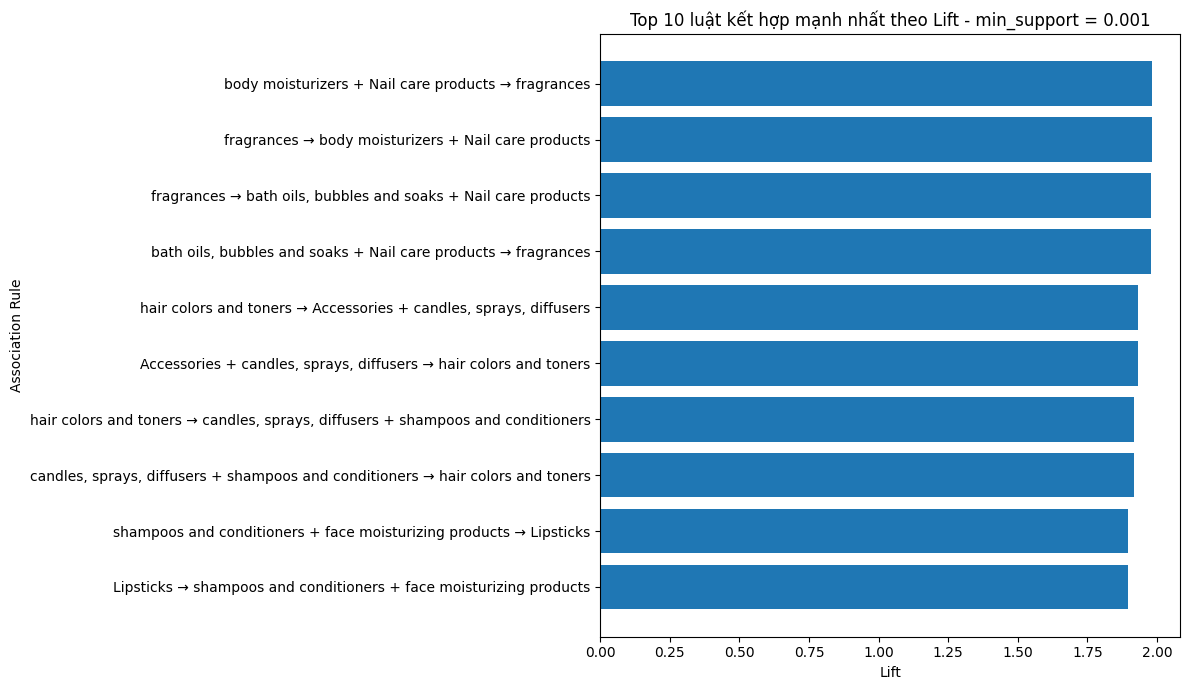

In [ ]:
plot_df = top_rules_by_lift.head(10).copy()
plot_df["rule"] = plot_df["antecedents_str"] + " → " + plot_df["consequents_str"]
plot_df = plot_df.sort_values("lift")

plt.figure(figsize=(12, 7))
plt.barh(plot_df["rule"], plot_df["lift"])
plt.xlabel("Lift")
plt.ylabel("Association Rule")
plt.title("Top 10 luật kết hợp mạnh nhất theo Lift - min_support = 0.001")
plt.tight_layout()
plt.show()

### Nhận xét biểu đồ Lift

Các luật có `lift` cao nhất chủ yếu là các combo nhỏ, xuất hiện với số đơn không quá lớn.

Vì vậy, `lift` giúp phát hiện mối liên kết mạnh, nhưng khi ra quyết định kinh doanh cần ưu tiên thêm các chỉ số như:

- `order_count`
- `confidence`
- `potential_score`

## 10. Phân tích nhóm hàng xuất hiện trong các combo mạnh

Ta thống kê các `Category` xuất hiện nhiều trong top 20 luật có lift cao nhất để xem nhóm hàng nào đóng vai trò trung tâm.

,Category,Appearances_in_top_rules
0,Hair care,16
1,Home and Accessories,14
2,Body care,10
3,Make up,6
4,Face care,4


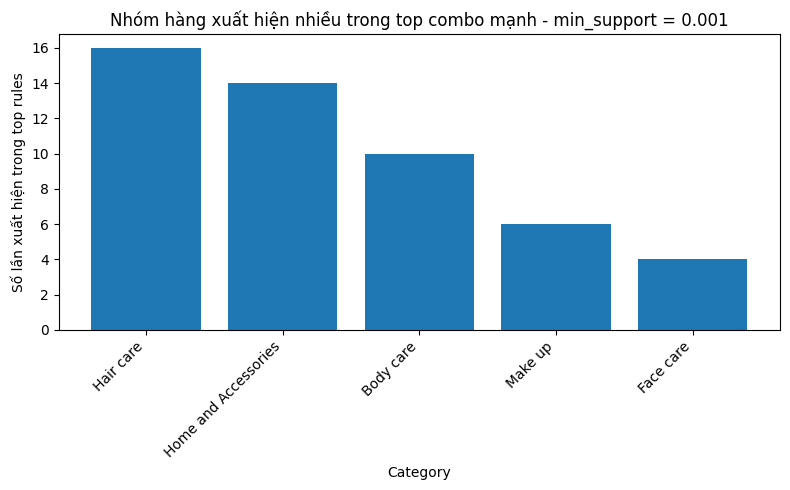

In [ ]:
top_n = 20
top_combo_rules = top_rules_by_lift.head(top_n).copy()

category_list = []

for _, row in top_combo_rules.iterrows():
    for cat in row["antecedent_category"].split(", "):
        category_list.append(cat)
    for cat in row["consequent_category"].split(", "):
        category_list.append(cat)

category_count = pd.Series(category_list).value_counts().reset_index()
category_count.columns = ["Category", "Appearances_in_top_rules"]

display(category_count)

plt.figure(figsize=(8, 5))
plt.bar(category_count["Category"], category_count["Appearances_in_top_rules"])
plt.xlabel("Category")
plt.ylabel("Số lần xuất hiện trong top rules")
plt.title("Nhóm hàng xuất hiện nhiều trong top combo mạnh - min_support = 0.001")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### Nhận xét nhóm hàng đặc thù

Khi chọn `min_support = 0.001`, các nhóm hàng xuất hiện nhiều trong top combo mạnh gồm:

- `Hair care`
- `Home and Accessories`
- `Body care`
- `Make up`
- `Face care`

Trong đó, `Hair care` và `Home and Accessories` xuất hiện khá nhiều ở các combo có lift cao.  
Điều này cho thấy khách hàng có xu hướng mua kèm giữa sản phẩm chăm sóc tóc, phụ kiện và các sản phẩm chăm sóc cá nhân.

## 11. Kết luận và đề xuất

### 1. Combo nào có sức mạnh liên kết lớn nhất?

Với `min_support = 0.001`, combo có sức mạnh liên kết lớn nhất theo `lift` là:

`fragrances → Nail care products + body moisturizers`

Combo này có `lift` cao nhất, nghĩa là mối liên kết giữa các nhóm hàng này mạnh hơn so với mua ngẫu nhiên.

Tuy nhiên, combo này có số đơn hàng thấp, chỉ khoảng 32 đơn. Vì vậy, nó phù hợp để xem như insight hành vi nhỏ, chưa nên dùng làm combo khuyến mãi chính.

### 2. Combo nào nên ưu tiên cho kinh doanh?

Combo có tính ứng dụng tốt hơn là:

`Accessories + brushes and applicators → Nail care products`

Lý do:

- Có khoảng 75 đơn hàng.
- Confidence khoảng 33.5%.
- Lift khoảng 1.68.
- Có ý nghĩa kinh doanh rõ ràng vì khách mua phụ kiện và dụng cụ làm đẹp dễ mua thêm sản phẩm chăm sóc móng.

### 3. Có sự xuất hiện của nhóm hàng đặc thù nào?

Có. Các nhóm hàng nổi bật gồm:

- `Hair care`
- `Home and Accessories`
- `Body care`
- `Make up`
- `Face care`

Trong đó, `Nail care products`, `brushes and applicators`, `body moisturizers`, `vitamins and supplements`, `shampoos and conditioners` là các nhóm sản phẩm thường xuất hiện trong combo tiềm năng.

### 4. Giải thích tâm lý khách hàng

Khách hàng mỹ phẩm thường mua theo routine làm đẹp thay vì mua sản phẩm riêng lẻ.

Ví dụ:

- Mua phụ kiện và dụng cụ làm đẹp thì dễ mua thêm sản phẩm chăm sóc móng.
- Mua dưỡng thể thì dễ mua thêm sản phẩm nail care hoặc sản phẩm chăm sóc cá nhân khác.
- Mua chăm sóc mặt và vitamin cho thấy khách hàng quan tâm đến làm đẹp cả bên ngoài lẫn bên trong.
- Mua dầu gội/dầu xả có thể đi kèm các sản phẩm body care để hoàn thiện routine chăm sóc cá nhân.

### 5. Đề xuất hành động

#### Đề xuất sắp xếp gian hàng

Nên đặt gần nhau các nhóm:

- `Accessories`, `brushes and applicators`, `Nail care products`
- `body moisturizers`, `Nail care products`, `vitamins and supplements`
- `face moisturizing products`, `vitamins and supplements`, `shampoos and conditioners`
- `bath oils, bubbles and soaks`, `shampoos and conditioners`, `Accessories`

#### Đề xuất khuyến mãi

Có thể triển khai các combo:

- Mua `Accessories + brushes and applicators` giảm giá khi mua thêm `Nail care products`.
- Mua `body moisturizers` gợi ý thêm `Nail care products`.
- Mua `face moisturizing products + vitamins and supplements` gợi ý thêm `shampoos and conditioners`.
- Tạo combo “Self-care routine” gồm `Body care + Hair care + Accessories`.

#### Đề xuất cho website

Khi khách thêm sản phẩm vào giỏ, website nên gợi ý:

- “Hoàn thiện routine làm đẹp của bạn”
- “Khách hàng thường mua kèm”
- “Thêm sản phẩm này để nhận ưu đãi combo”

Cách này giúp tăng khả năng cross-sell và tăng số lượng sản phẩm trung bình trên mỗi đơn hàng.